# Figure comparaison — overshoot par habitant (CBA vs PBA)

Figure "Overshoot / Safe Operating Space" en valeurs **par habitant**, pour
tous les scénarios (base-year, 2019 France/World/Europe, scénarios de
transition 2050). Pour chaque scénario, 2 bulles par LP :
- bulle pleine : comptabilité **consommation** (CBA, `d_cba.pkl`)
- bulle hachurée : comptabilité **production** (PBA, `F_x_dom.pkl`, part domestique uniquement)

Génère `figures/overshoot_safe_operating_space_per_capita.png`.

Variante en valeurs absolues (1 bulle/scénario) : voir `Overshoot multi-scénarios.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
if r"C:\Users\Arnaud\Documents\PlaneFR\notebooks" not in sys.path:
    sys.path.insert(0, r"C:\Users\Arnaud\Documents\PlaneFR\notebooks")

import matplotlib.pyplot as plt

from planefr_lib import config, io, processing
from planefr_lib.plot_overshoot import create_overshoot_safe_space_figure

Failed to read module file 'c:\Users\Arnaud\AppData\Local\Programs\Python\Python314\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Arnaud\AppData\Roaming\Python\Python314\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\Arnaud\AppData\Roaming\Python\Python314\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "c:\Users\Arnaud\AppData\Local\Programs\Python\Python314\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1398, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1335, in _find_and_load

## 1. Chargement des données et calcul par habitant

In [2]:
facteurs_carac_df = io.load_facteurs_carac()
seuils_df = io.load_seuils()
pop_df = io.load_population_df()

# Contrairement aux autres notebooks : inclut aussi les dossiers 2019_France /
# 2019_World / 2019_Europe_27, pour comparer les géographies en plus des scénarios.
scenario_folders = config.get_scenario_folders(exclude_2019=False, exclude_others=True)
scenario_names = [f.name for f in scenario_folders]
print(f"Scénarios trouvés ({len(scenario_folders)}): {scenario_names}")

Scénarios trouvés (3): ['2019_Europe_27', '2019_France', '2019_World']


In [3]:
all_scenarios_data = []
for scenario_folder in scenario_folders:
    print(f"Traitement : {scenario_folder.name}")
    data = processing.process_scenario_per_capita(scenario_folder, facteurs_carac_df, seuils_df, pop_df)
    print(f"  Sous-processus calculés : {list(data.keys())}")
    all_scenarios_data.append(data)

print(f"\n{len(all_scenarios_data)} scénarios traités.")

Traitement : 2019_Europe_27
  Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
Traitement : 2019_France
  Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']
Traitement : 2019_World
  Sous-processus calculés : ['N surplus', 'P surplus', 'Blue water consumption', 'Cropland use', 'GHG emissions', 'Biodiversity loss', 'Raw material consumption']

3 scénarios traités.


## 2. Figure overshoot par habitant (CBA + PBA)

C:\Users\Arnaud\Documents\PlaneFR\notebooks\planefr_lib\plot_overshoot.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[left_rect, 0.06, 0.98, top_rect])


Figure sauvegardée : C:\Users\Arnaud\Documents\PlaneFR\figures\overshoot_safe_operating_space_per_capita.png


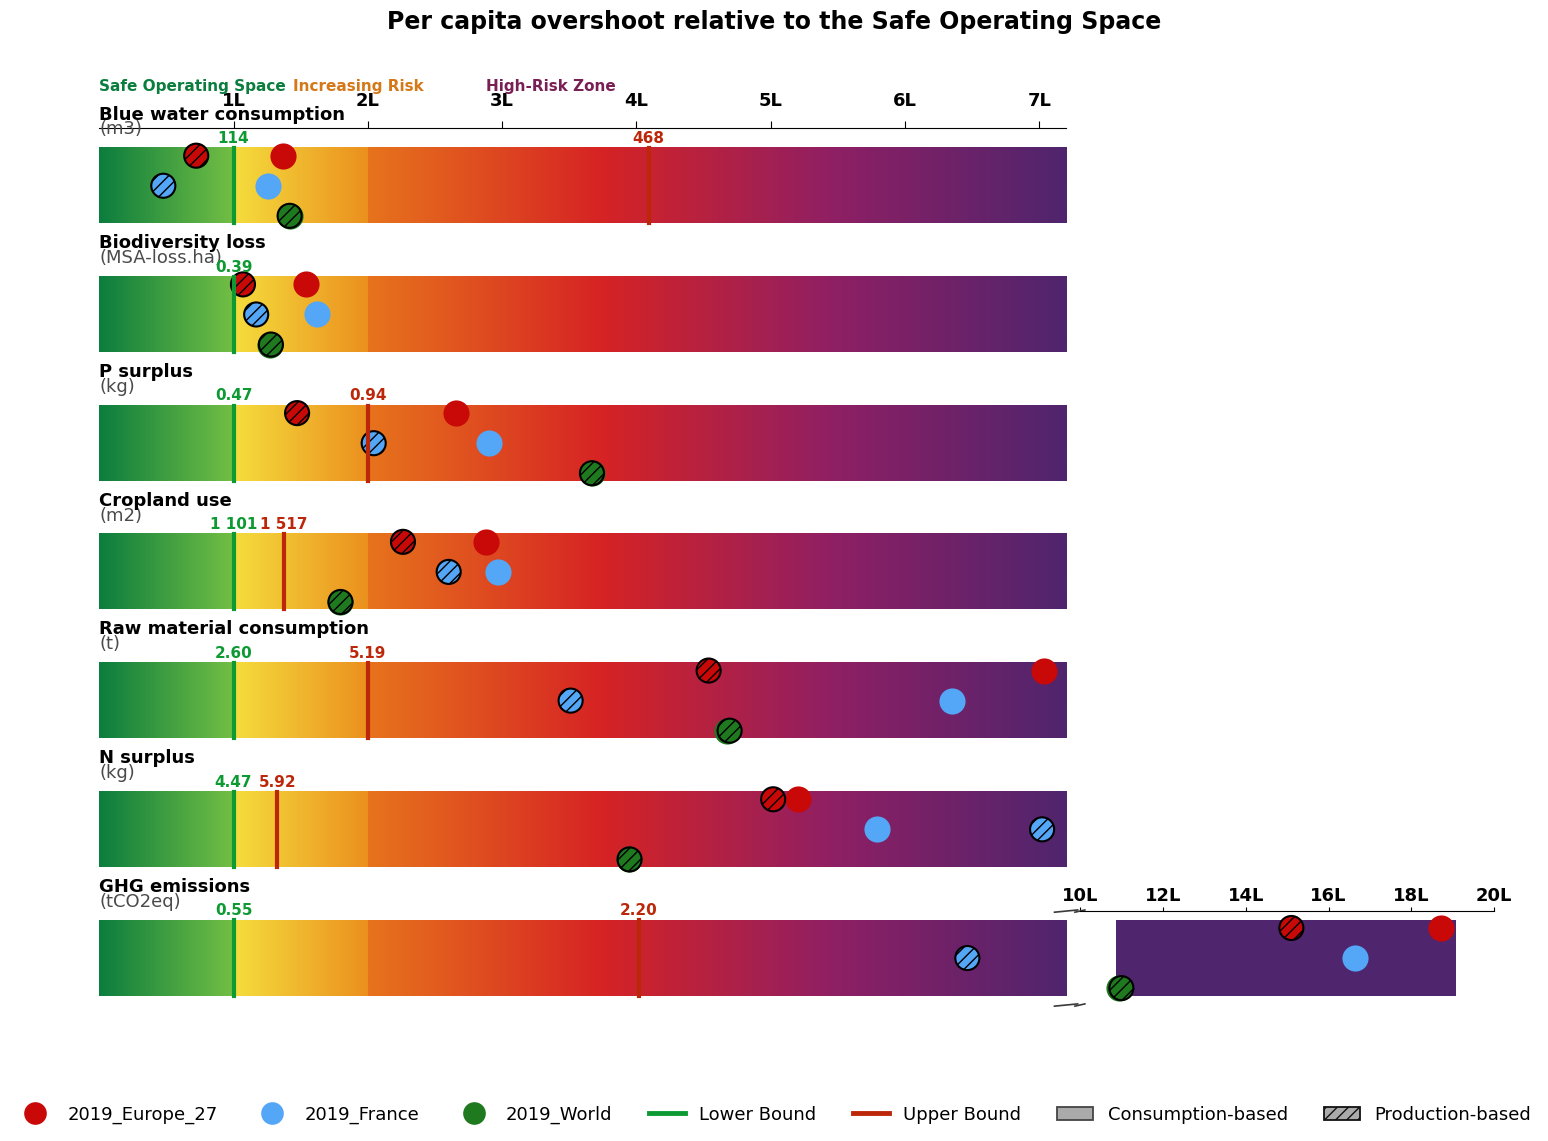

In [5]:
fig = create_overshoot_safe_space_figure(
    all_scenarios_data=all_scenarios_data,
    seuils_df=seuils_df,
    scenario_names=scenario_names,
    threshold_lb_row=config.THRESHOLD_LB_PER_CAPITA,
    threshold_ub_row=config.THRESHOLD_UB_PER_CAPITA,
    unit_row=config.UNIT_ROW_PER_CAPITA,
    x_main_max=7.2,
    show_pba=True, show_value_labels=False, title_above_bar=True,
    title="Per capita overshoot relative to the Safe Operating Space",
    sharing_principle="Equality 2100", pop_df=pop_df
)

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
output_path = config.FIGURES_DIR / "overshoot_safe_operating_space_per_capita.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Figure sauvegardée : {output_path}")
plt.show()